In [1]:
# Ensure working directory to project code folder
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

from importlib import reload

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [2]:
# configure matplotlib settings

from matplotlib import pyplot as plt

plt.rcParams.update(
    {
        "font.size": 12,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 14,
        "ytick.labelsize": 14,
        "legend.fontsize": 8,
        "figure.titlesize": 18,
        "pdf.fonttype": 42,
    }
)
from matplotlib.gridspec import GridSpec

In [3]:
from GridMaze.analysis.distance_to_goal import distance_metrics as dm

cpd_summary_df = dm.get_distance_metric_CPD_summary_df()
weights_summary_df = dm.get_weight_metrics_summary_df()

Main figures (prelim)

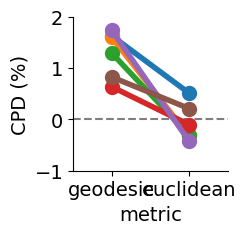

In [4]:
dm.plot_cross_subject_CPD_comparison(
    cpd_summary_df, comparison="geodesic_vs_euclidean", maze_names=["maze_1", "maze_2"], late_sessions=True
)

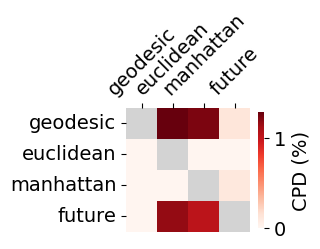

In [5]:
dm.plot_pairwise_CPD_summary(cpd_summary_df, late_sessions=True, maze_names=["maze_1", "maze_2"])

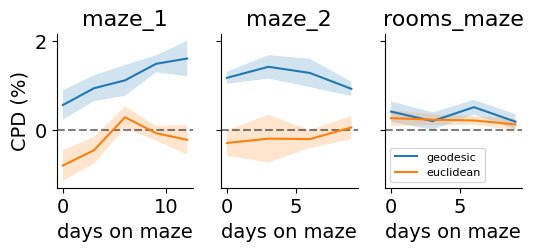

In [6]:
dm.plot_CPD_timeseries(cpd_summary_df, comparison="geodesic_vs_euclidean", group_days=3)

Supp figures (prelim)

geodesic_vs_euclidean: L1_ratio t-stat: -4.541, p-value: 6.162e-03


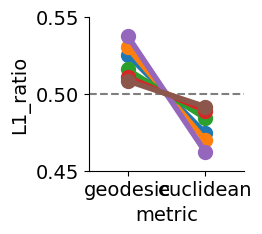

In [7]:
dm.plot_cross_subject_norm_comparison(
    weights_summary_df, comparison="geodesic_vs_euclidean", maze_names=["maze_1", "maze_2"], late_sessions=True
)

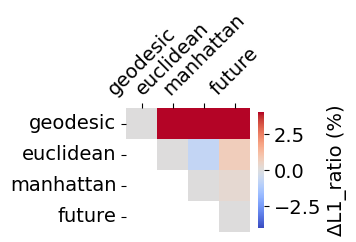

In [8]:
dm.plot_all_pairwise_metric_norm_diffs(
    weights_summary_df, norm_metric="L1_ratio", late_sessions=True, maze_names=["maze_1", "maze_2"]
)

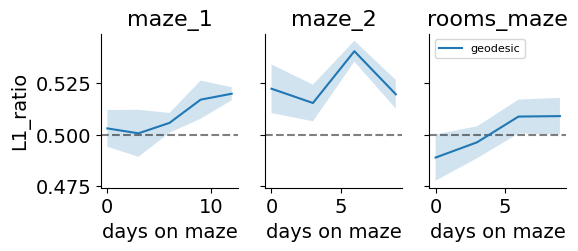

In [9]:
dm.plot_weights_comparison_timeseries(
    weights_summary_df, comparison="geodesic_vs_euclidean", plot_metric="geodesic", group_days=3
)

Characterising population tuning to distance to goal

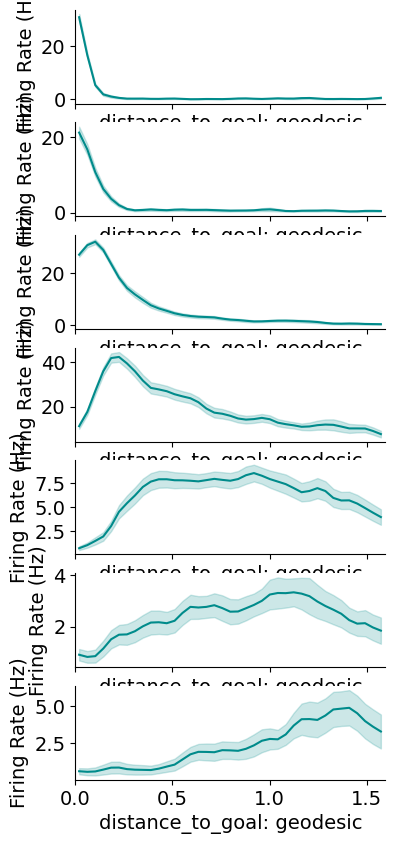

In [24]:
# plot some individual units

from GridMaze.analysis.core import get_clusters as gc

reload(gc)

example_clusters = [
    "m2.2022-07-03.maze_cluster43",
    "m2.2022-07-03.maze_cluster31",
    "m3.2022-07-02.maze_cluster44",
    "m2.2022-07-03.maze_cluster9",
    "m3.2022-07-01.maze_cluster38",
    "m6.2022-07-02.maze_cluster40",
    "m2.2022-07-03.maze_cluster49",
    # "m3.2022-07-08.maze_cluster96",
]

f, axes = plt.subplots(7, 1, figsize=(4, 10), sharex=True)

for cluster, ax in zip(example_clusters, axes.flatten()):
    Cluster = gc.get_cluster(cluster)
    Cluster.plot_tuning(feature="distance_to_goal", ax=ax)

In [ ]:
from GridMaze.analysis.distance_to_goal import population_tuning as pt

In [ ]:
fit_summary_df = pt.get_tuning_fits_summary_df()

clusters.distanceTuningMetrics.parquet not found for m8.2022-07-26.maze


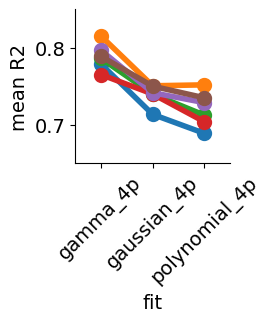

In [12]:
pt.plot_cross_subject_curve_fit_comparison(fit_summary_df)

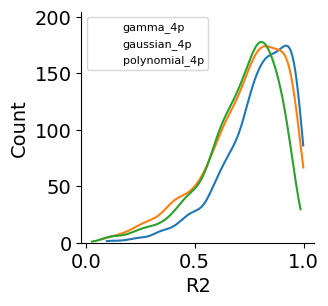

In [13]:
pt.plot_curve_fit_distributions(fit_summary_df)